# Using Custom Datasets with PrivacyGuard

## Introduction

PrivacyGuard provides built-in support for CIFAR-10, but many real-world privacy auditing
scenarios involve custom datasets — tabular data, domain-specific images, embeddings, etc.

This tutorial demonstrates how to use the `CustomDataset` class to plug **any** data
into the PrivacyGuard pipeline. We will:

1. Create a synthetic tabular dataset and wrap it with `CustomDataset`
2. Train a target model and shadow models using `SimpleMLP`
3. Run a **Likelihood Ratio Attack** (LiRA) with shadow models — both online and offline variants
4. Analyze and compare the results

### Why Custom Datasets?

Privacy risks are not limited to image classifiers. Any model trained on sensitive data
(medical records, financial data, user behavior logs) can leak information about its
training set. `CustomDataset` makes it easy to audit these models with PrivacyGuard.

## Environment Set-Up

In [ ]:
# Optionally create a conda environment for installing packages.
# If executing from Google Colab, skip this step.
!conda create -n privacy_guard python=3.12
!conda activate privacy_guard

In [ ]:
%cd /content
!git clone https://github.com/facebookresearch/PrivacyGuard.git

In [ ]:
%cd /content/PrivacyGuard
!ls
!pip install -e .

## Setup and Imports

In [ ]:
from typing import Any, Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from numpy.typing import NDArray

# PrivacyGuard imports
from privacy_guard.shadow_model_training.dataset import (
    CustomDataset,
    create_shadow_datasets,
)
from privacy_guard.shadow_model_training.model import create_mlp_model
from privacy_guard.shadow_model_training.training import (
    get_transformed_logits,
    prepare_lira_data,
    train_model,
)
from privacy_guard.attacks.lira_attack import LiraAttack
from privacy_guard.analysis.mia.aggregate_analysis_input import AggregationType
from privacy_guard.analysis.mia.analysis_node import AnalysisNode
from torch.utils.data import DataLoader, Subset

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

## Step 1: Create a Custom Dataset

We generate a synthetic tabular classification dataset using Gaussian clusters.
Each class has its own cluster center in a high-dimensional feature space.

This simulates a realistic scenario: imagine predicting disease risk from patient
features, classifying user behavior from activity logs, or categorizing transactions
from financial records.

The `CustomDataset` class accepts:
- **data**: A numpy array or PyTorch tensor of shape `(n_samples, ...)`
- **targets**: A numpy array or PyTorch tensor of shape `(n_samples,)`
- **transform** (optional): A callable applied to each sample on access

In [13]:
# Dataset parameters
NUM_CLASSES = 5
NUM_FEATURES = 100
SAMPLES_PER_CLASS = 1000
NOISE_STD = 3.0

n_total = NUM_CLASSES * SAMPLES_PER_CLASS

# Generate class centers
class_centers = np.random.randn(NUM_CLASSES, NUM_FEATURES).astype(np.float32)

# Generate data: each sample = class_center + Gaussian noise
all_labels = np.repeat(np.arange(NUM_CLASSES), SAMPLES_PER_CLASS)
all_features = (
    class_centers[all_labels] + NOISE_STD * np.random.randn(n_total, NUM_FEATURES)
).astype(np.float32)

# Shuffle
perm = np.random.permutation(n_total)
all_features = all_features[perm]
all_labels = all_labels[perm]

# Split into train (80%) and test (20%)
split = int(0.8 * n_total)
train_features, test_features = all_features[:split], all_features[split:]
train_labels, test_labels = all_labels[:split], all_labels[split:]

# Create CustomDataset instances
train_dataset = CustomDataset(train_features, train_labels)
test_dataset = CustomDataset(test_features, test_labels)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Test dataset:  {len(test_dataset)} samples")
print(f"Number of classes: {train_dataset.num_classes}")
print(f"Input shape: {train_dataset.input_shape}")

Train dataset: 4000 samples
Test dataset:  1000 samples
Number of classes: 5
Input shape: torch.Size([100])


### Visualize the Data

Let's project the first two dimensions to get a sense of the class separation.

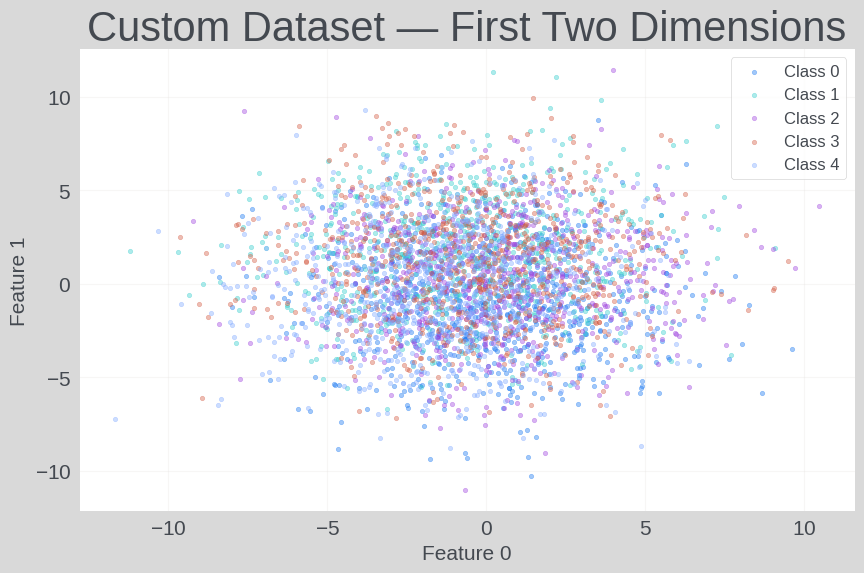

In [14]:
plt.figure(figsize=(10, 6))
for c in range(NUM_CLASSES):
    mask = train_labels == c
    plt.scatter(
        train_features[mask, 0],
        train_features[mask, 1],
        alpha=0.4,
        label=f"Class {c}",
        s=10,
    )
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.title("Custom Dataset — First Two Dimensions")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Step 2: Train a Target Model

We use `create_mlp_model` to build a simple feedforward network.
This model automatically adapts to the input dimension and number of classes
of our custom dataset.

In [15]:
# Create the model
input_dim = train_dataset.input_shape[0]  # number of features
num_classes = train_dataset.num_classes

target_model = create_mlp_model(
    input_dim=input_dim,
    num_classes=num_classes,
    hidden_dims=[256, 128],
).to(DEVICE)

print(target_model)

# Create data loaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Train the model
EPOCHS = 30
target_model = train_model(
    target_model, train_loader, test_loader, epochs=EPOCHS, device=DEVICE
)

SimpleMLP(
  (network): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU(inplace=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=128, out_features=5, bias=True)
  )
)
Epoch 1/30
Training - Loss: 0.6406, Acc: 76.86%
Testing - Acc: 90.70%
Epoch 2/30
Training - Loss: 0.1758, Acc: 94.05%
Testing - Acc: 92.20%
Epoch 3/30
Training - Loss: 0.1164, Acc: 96.60%
Testing - Acc: 92.50%
Epoch 4/30
Training - Loss: 0.0853, Acc: 97.93%
Testing - Acc: 92.70%
Epoch 5/30
Training - Loss: 0.0663, Acc: 98.51%
Testing - Acc: 92.60%
Epoch 6/30
Training - Loss: 0.0533, Acc: 98.84%
Testing - Acc: 92.70%
Epoch 7/30
Training - Loss: 0.0410, Acc: 99.27%
Testing - Acc: 92.70%
Epoch 8/30
Training - Loss: 0.0389, Acc: 99.32%


## Step 3: LiRA with Shadow Models on Custom Data

For a powerful privacy audit, we use the **Likelihood Ratio Attack (LiRA)**. This requires
training multiple shadow models on random subsets of the training data.

The key advantage of `CustomDataset` is that it integrates seamlessly with
`create_shadow_datasets` — the same function used for CIFAR-10.

In [16]:
# Create shadow datasets
NUM_SHADOWS = 8  # Using fewer for tutorial speed

shadow_datasets, target_shadow_dataset = create_shadow_datasets(
    train_dataset, n_shadows=NUM_SHADOWS, pkeep=0.5, seed=42
)

print(f"Number of shadow datasets: {len(shadow_datasets)}")
for i, (subset, _) in enumerate(shadow_datasets):
    print(f"  Shadow {i}: {len(subset)} samples")
print(f"  Target: {len(target_shadow_dataset[0])} samples")

Number of shadow datasets: 7
  Shadow 0: 2034 samples
  Shadow 1: 2041 samples
  Shadow 2: 2019 samples
  Shadow 3: 1960 samples
  Shadow 4: 2033 samples
  Shadow 5: 1965 samples
  Shadow 6: 2000 samples
  Target: 1948 samples


In [17]:
# Train the target model (on target shadow subset)
target_lira_model = create_mlp_model(
    input_dim=input_dim, num_classes=num_classes, hidden_dims=[256, 128]
).to(DEVICE)

target_subset = target_shadow_dataset[0]
target_train_loader = DataLoader(target_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print("Training target model for LiRA...")
target_lira_model = train_model(
    target_lira_model, target_train_loader, test_loader, epochs=EPOCHS, device=DEVICE
)

# Train shadow models
shadow_models = []
for i, (shadow_subset, _) in enumerate(shadow_datasets):
    print(f"\nTraining shadow model {i + 1}/{len(shadow_datasets)}...")
    shadow_model = create_mlp_model(
        input_dim=input_dim, num_classes=num_classes, hidden_dims=[256, 128]
    ).to(DEVICE)
    shadow_loader = DataLoader(shadow_subset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    shadow_model = train_model(
        shadow_model, shadow_loader, test_loader, epochs=EPOCHS, device=DEVICE
    )
    shadow_models.append(shadow_model)

Training target model for LiRA...
Epoch 1/30
Training - Loss: 1.0301, Acc: 61.88%
Testing - Acc: 85.80%
Epoch 2/30
Training - Loss: 0.2345, Acc: 92.71%
Testing - Acc: 88.90%
Epoch 3/30
Training - Loss: 0.1427, Acc: 96.25%
Testing - Acc: 89.20%
Epoch 4/30
Training - Loss: 0.0982, Acc: 97.81%
Testing - Acc: 89.90%
Epoch 5/30
Training - Loss: 0.0744, Acc: 98.70%
Testing - Acc: 90.50%
Epoch 6/30
Training - Loss: 0.0555, Acc: 99.38%
Testing - Acc: 90.60%
Epoch 7/30
Training - Loss: 0.0505, Acc: 99.32%
Testing - Acc: 90.60%
Epoch 8/30
Training - Loss: 0.0413, Acc: 99.58%
Testing - Acc: 90.80%
Epoch 9/30
Training - Loss: 0.0378, Acc: 99.69%
Testing - Acc: 91.20%
Epoch 10/30
Training - Loss: 0.0327, Acc: 99.79%
Testing - Acc: 90.90%
Epoch 11/30
Training - Loss: 0.0233, Acc: 99.90%
Testing - Acc: 91.00%
Epoch 12/30
Training - Loss: 0.0270, Acc: 99.90%
Testing - Acc: 91.30%
Epoch 13/30
Training - Loss: 0.0228, Acc: 99.90%
Testing - Acc: 91.00%
Epoch 14/30
Training - Loss: 0.0202, Acc: 99.95%
Tes

In [18]:
# Extract logits from all models over the full training dataset
full_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Extracting target model logits...")
target_logits = get_transformed_logits(target_lira_model, full_train_loader, DEVICE)

shadow_logits_list = []
for i, shadow_model in enumerate(shadow_models):
    print(f"Extracting shadow model {i + 1}/{len(shadow_models)} logits...")
    shadow_logits_list.append(
        get_transformed_logits(shadow_model, full_train_loader, DEVICE)
    )

shadow_logits = np.array(shadow_logits_list)
print(f"\nTarget logits shape: {target_logits.shape}")
print(f"Shadow logits shape: {shadow_logits.shape}")

Extracting target model logits...
Model accuracy: 0.9575
Extracting shadow model 1/7 logits...
Model accuracy: 0.9653
Extracting shadow model 2/7 logits...
Model accuracy: 0.9633
Extracting shadow model 3/7 logits...
Model accuracy: 0.9647
Extracting shadow model 4/7 logits...
Model accuracy: 0.9610
Extracting shadow model 5/7 logits...
Model accuracy: 0.9605
Extracting shadow model 6/7 logits...
Model accuracy: 0.9603
Extracting shadow model 7/7 logits...
Model accuracy: 0.9615

Target logits shape: (4000, 1)
Shadow logits shape: (7, 4000, 1)


In [19]:
# Prepare data for LiRA
df_train_online, df_test_online, df_train_offline, df_test_offline = prepare_lira_data(
    target_logits, shadow_logits, target_shadow_dataset, shadow_datasets
)

print(f"Online train shape: {df_train_online.shape}")
print(f"Online test shape:  {df_test_online.shape}")

4000
Online train shape: (1948, 6)
Online test shape:  (2052, 6)


In [20]:
# Run Online LiRA attack
online_lira = LiraAttack(
    df_train_merge=df_train_online,
    df_test_merge=df_test_online,
    row_aggregation=AggregationType.NONE,
    use_fixed_variance=True,
    std_dev_type="mix",
    online_attack=True,
)
online_results = online_lira.run_attack()

# Run Offline LiRA attack
offline_lira = LiraAttack(
    df_train_merge=df_train_offline,
    df_test_merge=df_test_offline,
    row_aggregation=AggregationType.NONE,
    use_fixed_variance=True,
    std_dev_type="shadows_out",
    online_attack=False,
)
offline_results = offline_lira.run_attack()

print("LiRA attacks completed.")

LiRA attacks completed.


## Step 4: Analyze and Compare Results

In [21]:
def run_analysis(attack_results: Any, name: str) -> Dict[str, Any]:
    """Run AnalysisNode and print results."""
    node = AnalysisNode(
        analysis_input=attack_results,
        delta=1e-5,
        n_users_for_eval=min(
            len(attack_results.df_train_user), len(attack_results.df_test_user)
        ),
        num_bootstrap_resampling_times=1000,
        show_progress=False,
    )
    results = node.compute_outputs()

    print(f"\n=== {name} ===")
    print(
        f"Accuracy: {results['accuracy']:.4f} "
        f"(95% CI: [{results['accuracy_ci'][0]:.4f}, {results['accuracy_ci'][1]:.4f}])"
    )
    print(
        f"AUC:      {results['auc']:.4f} "
        f"(95% CI: [{results['auc_ci'][0]:.4f}, {results['auc_ci'][1]:.4f}])"
    )
    print(f"Epsilon (TPR=1%, UB): {results['eps_tpr_ub'][0]:.4f}")
    print(f"Epsilon (TPR=1%, LB): {results['eps_tpr_lb'][0]:.4f}")
    return results


online_analysis = run_analysis(online_results, "Online LiRA")
offline_analysis = run_analysis(offline_results, "Offline LiRA")

I0303 113453.075 analysis_node.py:303] Train/Test unique users: 1948/2052
I0303 113453.363 mia_results.py:193] TNR: 0.04517, FNR: 0.0, emp eps: 2.16682, tnr@fnr0.001: 0.04517, eps@fnr0.001: 0.02977, auc 0.65352 accuracy 0.61345, 
I0303 113453.363 analysis_node.py:310] Epsilon CP: 2.1668151955334354
I0303 113454.733 analysis_node.py:303] Train/Test unique users: 1948/2052



=== Online LiRA ===
Accuracy: 0.6235 (95% CI: [0.6093, 0.6386])
AUC:      0.6667 (95% CI: [0.6497, 0.6830])
Epsilon (TPR=1%, UB): 7.5746
Epsilon (TPR=1%, LB): 1.8961


I0303 113455.023 mia_results.py:193] TNR: 1.0, FNR: 0.99487, emp eps: -0.00213, tnr@fnr0.001: 0.0, eps@fnr0.001: -0.0038, auc 0.5157 accuracy 0.52002, 


I0303 113455.023 analysis_node.py:310] Epsilon CP: -0.0021271328306005184



=== Offline LiRA ===
Accuracy: 0.5125 (95% CI: [0.5033, 0.5241])
AUC:      0.4998 (95% CI: [0.4824, 0.5171])
Epsilon (TPR=1%, UB): 1.0977
Epsilon (TPR=1%, LB): -0.3576


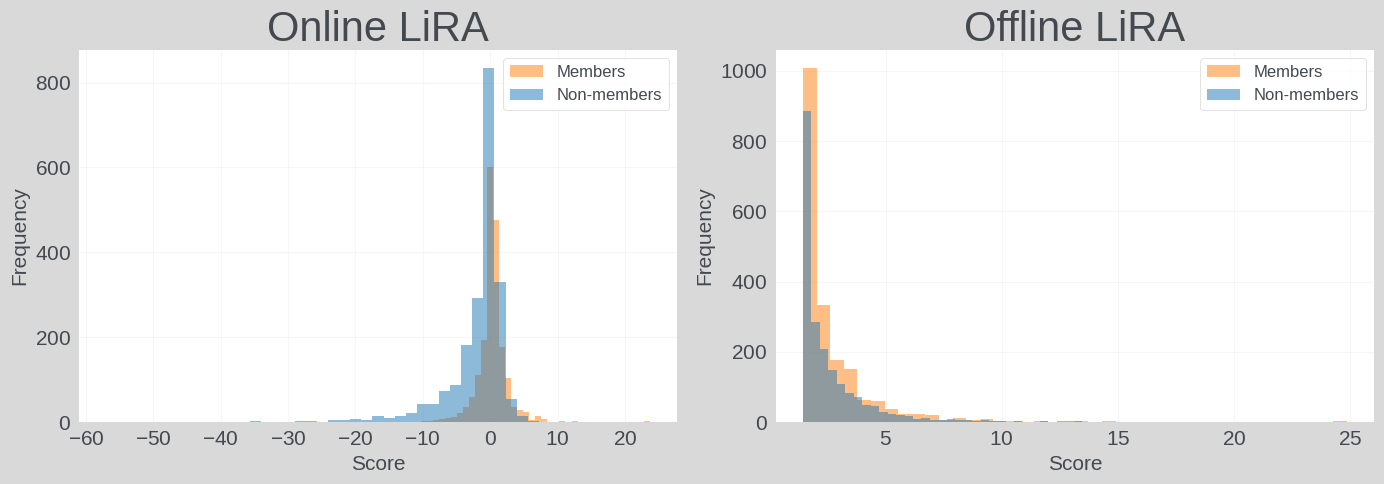

In [22]:
# Compare score distributions for Online vs Offline LiRA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

attack_data = [
    (online_results, "Online LiRA"),
    (offline_results, "Offline LiRA"),
]

for ax, (results, title) in zip(axes, attack_data):
    ax.hist(
        results.df_train_user["score"],
        bins=40,
        alpha=0.5,
        label="Members",
        color="tab:orange",
    )
    ax.hist(
        results.df_test_user["score"],
        bins=40,
        alpha=0.5,
        label="Non-members",
        color="tab:blue",
    )
    ax.set_xlabel("Score")
    ax.set_ylabel("Frequency")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Bringing Your Own Data

To use `CustomDataset` with your own data, you only need:

```python
import numpy as np
from privacy_guard.shadow_model_training.dataset import CustomDataset

# Load your data (any source: CSV, database, API, etc.)
X_train = np.load("my_train_features.npy")  # shape: (n_samples, n_features)
y_train = np.load("my_train_labels.npy")    # shape: (n_samples,)
X_test = np.load("my_test_features.npy")
y_test = np.load("my_test_labels.npy")

train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

# Now use these with any PrivacyGuard attack:
# - LossAttack
# - LiRA (via create_shadow_datasets)
# - RMIA (via create_rmia_datasets)
```

### Supported data types

| Data Type | data shape | Model |
|-----------|------------|-------|
| Tabular (flat features) | `(n, d)` | `create_mlp_model(input_dim=d, ...)` |
| Images (grayscale) | `(n, 1, h, w)` | `create_model(num_classes=k, input_channels=1)` |
| Images (RGB) | `(n, 3, h, w)` | `create_model(num_classes=k, input_channels=3)` |
| Embeddings | `(n, embed_dim)` | `create_mlp_model(input_dim=embed_dim, ...)` |

### Key properties

- `dataset.num_classes` — number of unique labels
- `dataset.input_shape` — shape of a single sample (e.g., `(100,)` or `(3, 32, 32)`)

## Conclusion

In this tutorial we showed how to:

1. **Wrap any data** in `CustomDataset` for use with PrivacyGuard
2. **Choose the right model**: `create_mlp_model` for tabular data, `create_model` for images
3. **Run LiRA** (online and offline) on custom data — no pipeline changes needed
4. **Analyze results** using `AnalysisNode` to measure accuracy, AUC, and epsilon

### Key Takeaways

- `CustomDataset` makes PrivacyGuard **dataset-agnostic** — you are not limited to CIFAR-10
- The same `create_shadow_datasets` and `create_rmia_datasets` functions work with any dataset
- Privacy risks exist for **all** types of models and data — not just image classifiers

### Mitigating Privacy Risks

If your audit reveals high epsilon or AUC values, consider:

1. **Differential Privacy (DP-SGD)**: Train with provable privacy guarantees
2. **Regularization**: Stronger weight decay, dropout, or early stopping
3. **Reduce model capacity**: Smaller models memorize less
4. **More training data**: Larger datasets dilute individual influence